In [3]:
import json
import dataclasses

import colorcet
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [50]:
config_id = 2
instance_id = 1
filename = f"_outputs/output-{config_id}-{instance_id}.h5"

with h5py.File(filename, "r") as store:
    metadata = store["metadata"]
    config = json.loads(metadata["config_source"][()])
    config_used = json.loads(metadata["config"][()])

    production_overrides = config_used["sampling"]["phases"][-1]
    production_name = production_overrides["name"]
    phase_store = store["phases"][production_name]

    positions_history = []
    for frame_index, step_key in enumerate(phase_store[".steps"]):
        sample = phase_store[step_key]
        positions = sample["positions"][:]
        positions_history.append(positions)
    positions_history = np.array(positions_history)

frame_count = len(positions_history)

In [51]:
chain_used, = config_used["chains"]
chain_length = chain_used["length"]
default_valency = config_used["association"]["valency"]

selector_a = np.full(chain_length, False)
for feature in chain_used.get("association_features", []):
    is_a = False
    match feature:
        case {"valency": valency}:
            is_a = (valency < default_valency)

        case {"association": _} | {"dissociation": _}:
            assoc = feature.get("association", 1)
            dissoc = feature.get("dissociation", 1)
            is_a = (assoc < dissoc)

    if is_a:
        site = feature["site"]
        start = site["start"]
        end = site["end"]
        selector_a[start:end] = True

selector_b = ~selector_a

phi  0.115


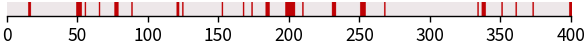

In [52]:
fig, ax = plt.subplots(figsize=(3.0, 0.3))

ax.matshow(
    selector_a[None, :],
    origin="lower",
    extent=[0, chain_length, 1, 0],
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap=colorcet.m_coolwarm,
    interpolation="kaiser",
)
set_axis(ax, "bottom")

print("phi ", selector_a.mean())

pass

In [53]:
def drop_keys(d: dict, *arg: any) -> dict:
    return {key: value for key, value in d.items() if key not in arg}

In [54]:
sampling_config = config["sampling"]
production_config = {**drop_keys(sampling_config, "phases"), **production_overrides}
frame_interval = production_config["timestep"] * production_config["sampling_interval"]

In [55]:
def collect_msds(
    paths: np.ndarray,  # (time, particle, dim)
    lag: int,
) -> np.ndarray:
    squared_dists = np.zeros((lag, paths.shape[1]))
    for t in range(0, paths.shape[0] - lag):
        delta = paths[t:t + lag] - paths[t]
        squared_dists += (delta ** 2).sum(-1)
    return squared_dists / (paths.shape[0] - lag)


def subtract_centroid(paths: np.ndarray) -> np.ndarray:
    return paths - paths.mean(axis=1, keepdims=True)


def compute_rg(positions: np.ndarray) -> np.ndarray:
    centroid = positions.mean(axis=-2, keepdims=True)
    return np.sqrt((positions - centroid).var(axis=-2).sum(axis=-1))

In [56]:
lag_frames = 11
lag_time = lag_frames * frame_interval

paths = subtract_centroid(positions_history)
msd = collect_msds(paths, lag=lag_frames).mean(1)

x = frame_interval * np.arange(len(msd))
y = msd
alpha, beta = fit_power_law(x, y)

if selector_a.sum() > 0:
    y = msd_a = collect_msds(paths[:, selector_a], lag=lag_frames).mean(1)
    alpha_a, beta_a = fit_power_law(x, y)

if selector_b.sum() > 0:
    y = msd_b = collect_msds(paths[:, selector_b], lag=lag_frames).mean(1)
    alpha_b, beta_b = fit_power_law(x, y)

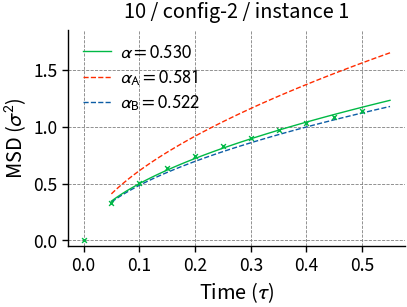

In [57]:
color = "C:g"
color_a = "C:r"
color_b = "C:b"

fig, ax = plt.subplots(figsize=(2.1, 1.6))

x = np.arange(len(msd)) * frame_interval
y = msd
ax.scatter(x, y, s=3, marker="x", color=color, zorder=5)

x = powerlaw_x = np.logspace(np.log10(frame_interval), np.log10(lag_time), num=100)
y = powerlaw_y = x**alpha * beta
s = r"$ \alpha = %.3f $" % alpha
ax.plot(x, y, color=color, label=s, zorder=4)

if selector_a.sum() > 0:
    x = np.logspace(np.log10(frame_interval), np.log10(lag_time), num=100)
    y = x**alpha_a * beta_a
    s = r"$ \alpha_\mathrm{A} = %.3f $" % alpha_a
    ax.plot(x, y, color=color_a, ls="--", label=s, zorder=3)

if selector_b.sum() > 0:
    x = np.logspace(np.log10(frame_interval), np.log10(lag_time), num=100)
    y = x**alpha_b * beta_b
    s = r"$ \alpha_\mathrm{B} = %.3f $" % alpha_b
    ax.plot(x, y, color=color_b, ls="--", label=s, zorder=3)


ax.set_xlabel(r"Time ($ \tau $)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")
ax.set_title(f"10 / config-{config_id} / instance {instance_id}")
ax.legend()

ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
# ax.set_xscale("log")
# ax.set_yscale("log")
ax.grid(True, zorder=1)
ax.set_ylim(-0.05, 1.85)

set_axis(ax, "left bottom")

pass